# Spring Leaf Marketing Response

## Loading in data

In [1]:
ls

 Decision-tree.png
 LDA.png
 README.md
 Random-forest.png
'Spring Leaf Data Cleaning.ipynb'
'Spring Leaf Data Visualization.ipynb'
 UTA-DataScience-Logo.png
'correlation heat map of numericals.png:Zone.Identifier'
 correlation-heat-map-of-numericals.png
 df_balanced.csv
 important_balanced.csv
 train.csv


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data

df = pd.read_csv('important_balanced.csv', low_memory = False)

In [24]:
## Data cleaning

df.shape

#checking for NA
np.any(df.isnull())
df.isna().sum()

target         1000
VAR_0885       1000
VAR_1823       1000
VAR_0070       1001
VAR_0062       1001
               ... 
VAR_0342_FF    1000
VAR_0353_R     1000
VAR_0325_S     1000
VAR_0283_S     1000
VAR_0005_N     1000
Length: 1899, dtype: int64

In [25]:
# Removing duplicate columns in the data set

df =df.loc[:,~df.T.duplicated()]
constant_features = [col for col in df.columns if df[col].nunique() == 1]

df = df.drop(constant_features, axis = 1)

df.head()

,target,VAR_0885,VAR_1823,VAR_0070,VAR_0062,VAR_0886,VAR_0061,VAR_1110,VAR_0071,VAR_1127,...,VAR_0352_U,VAR_0354_R,VAR_0001_H,VAR_0342_-1,VAR_0352_O,VAR_0342_FF,VAR_0353_R,VAR_0325_S,VAR_0283_S,VAR_0005_N
0,1.0,100.0,107.0,0.0,1.0,76.0,1.0,107.0,10.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,100.0,101.0,0.0,1.0,35.0,1.0,101.0,0.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,100.0,70.0,0.0,2.0,73.0,2.0,57.0,0.0,83.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,100.0,41.0,0.0,1.0,82.0,1.0,63.0,0.0,91.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,70.0,92.0,1.0,2.0,36.0,2.0,108.0,1.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
#Spliting data into X, Y and droping ID column.
df = df.dropna(subset=['target'])
x = df.drop(['target'],axis = 1)
y = df['target']
x.head()

,VAR_0885,VAR_1823,VAR_0070,VAR_0062,VAR_0886,VAR_0061,VAR_1110,VAR_0071,VAR_1127,VAR_0069,...,VAR_0352_U,VAR_0354_R,VAR_0001_H,VAR_0342_-1,VAR_0352_O,VAR_0342_FF,VAR_0353_R,VAR_0325_S,VAR_0283_S,VAR_0005_N
0,100.0,107.0,0.0,1.0,76.0,1.0,107.0,10.0,20.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100.0,101.0,0.0,1.0,35.0,1.0,101.0,0.0,20.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100.0,70.0,0.0,2.0,73.0,2.0,57.0,0.0,83.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100.0,41.0,0.0,1.0,82.0,1.0,63.0,0.0,91.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,70.0,92.0,1.0,2.0,36.0,2.0,108.0,1.0,41.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
#Checking data types
x.info()

#Turning int64 to float64
int_cols = x.select_dtypes(include = 'int64').columns
x[int_cols] = x[int_cols].astype('float64')

x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Columns: 1799 entries, VAR_0885 to VAR_0005_N
dtypes: float64(1799)
memory usage: 13.7 MB
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Columns: 1799 entries, VAR_0885 to VAR_0005_N
dtypes: float64(1799)
memory usage: 13.7 MB


In [28]:
# this variable is zip codes it needs to be an object variable
x['VAR_0241'] = pd.to_numeric(df['VAR_0241'])
x['VAR_0241'] = x['VAR_0241'].astype(object)

In [29]:
#splitting Quantitative and qualitative columns
x_num = x.select_dtypes(include='float64')
x_cat = x.select_dtypes(exclude='float64')

catlist = x_cat.columns
numeric_columns = x_num.columns


In [30]:
x_cat['VAR_0241']

0      43756.0
1      78217.0
2      33544.0
3      36575.0
4      75205.0
        ...   
995    60901.0
996    31313.0
997    90746.0
998    70006.0
999    46120.0
Name: VAR_0241, Length: 1000, dtype: object

In [31]:

lower_bound = x_num.quantile(0.01)
upper_bound = x_num.quantile(0.95)

x_num = x_num.clip(lower=lower_bound, upper=upper_bound, axis=1)
numeric_columns = x_num.columns

In [32]:
x_num = x_num.dropna(axis=1, how='all') # Drop columns that are all NaNs

In [33]:
#Encoding the categorical data
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, auc

In [34]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [35]:
cat_pipeline = Pipeline([
    ('to_str', FunctionTransformer(lambda x: x.astype(str))),
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [36]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, x_num.columns),
    ('cat', cat_pipeline, x_cat.columns)
])

In [37]:
x_all_array = preprocessor.fit_transform(x)
encoded_columns = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(x_cat.columns)
all_columns = list(x_num.columns) + list(encoded_columns)
x_all = pd.DataFrame(x_all_array, columns=all_columns, index=x.index)


In [38]:
selector = VarianceThreshold(threshold=0.01)
x_all = selector.fit_transform(x_all)
selected_columns = [col for col, keep in zip(all_columns, selector.get_support()) if keep]
x_all = pd.DataFrame(x_all, columns=selected_columns, index=x.index)

In [39]:
mi_scores = mutual_info_classif(x_all, y, discrete_features='auto')
mi_series = pd.Series(mi_scores, index=x_all.columns).sort_values(ascending=False)


In [40]:
x_all = x_all.drop(columns=mi_series[mi_series > 0.9].index)
x_all = x_all.drop(columns=mi_series[mi_series < 0.005].index)

In [41]:
x_all

,VAR_0885,VAR_1823,VAR_0070,VAR_0062,VAR_0886,VAR_0061,VAR_1110,VAR_0071,VAR_1127,VAR_0069,...,VAR_0147,VAR_0146,VAR_0163,VAR_0164,VAR_0941,VAR_0924,VAR_1736,VAR_0173,VAR_0175,VAR_0183
0,0.264719,-0.412033,-0.258392,-0.305741,0.511138,-0.300190,0.100297,0.012538,-0.639120,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,-0.717696,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
1,0.264719,-0.427924,-0.258392,-0.305741,-1.217674,-0.300190,0.053349,-0.262744,-0.639120,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,-0.717696,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
2,0.264719,-0.510028,-0.258392,-0.149108,0.384639,-0.112759,-0.290937,-0.262744,0.111510,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,0.308186,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
3,0.264719,-0.586835,-0.258392,-0.305741,0.764135,-0.300190,-0.243989,-0.262744,0.206829,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,-0.643133,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
4,0.263503,-0.451760,-0.222111,-0.149108,-1.175507,-0.112759,0.108121,-0.235215,-0.388910,-0.173486,...,-0.10097,-0.108656,-0.105028,7.891970,-0.643133,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.263382,-0.499434,-0.258392,-0.305741,-0.332185,-0.300190,-0.157918,-0.262744,-0.662950,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,0.308186,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
996,0.261558,-0.396142,-0.258392,-0.305741,-0.922511,-0.300190,-0.079671,-0.262744,-0.281677,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,-0.488865,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
997,0.264719,-0.422627,-0.258392,-0.305741,0.384639,-0.300190,0.068998,-0.262744,0.314061,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,-0.717696,-0.070888,0.160236,-0.135525,-0.117574,-0.110319
998,0.264719,-0.618617,-0.004431,-0.305741,1.523125,-0.300190,-0.150093,-0.070047,0.314061,-0.227461,...,-0.10097,-0.108656,-0.105028,-0.203332,-0.717696,-0.070888,0.160236,-0.135525,-0.117574,-0.110319


In [42]:
X_train, X_val, y_train, Y_val = train_test_split(
    x_all, y, test_size = 0.2, random_state=100
)

In [43]:
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("ROC AUC:", roc_auc_score(y_val, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred))
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
    plt.legend(loc="lower right")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()


--- Linear Discriminant Analysis ---
Accuracy: 0.555
ROC AUC: 0.5064057651886698
Confusion Matrix:
 [[59 38]
 [51 52]]
              precision    recall  f1-score   support

         0.0       0.54      0.61      0.57        97
         1.0       0.58      0.50      0.54       103

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.55       200
weighted avg       0.56      0.56      0.55       200



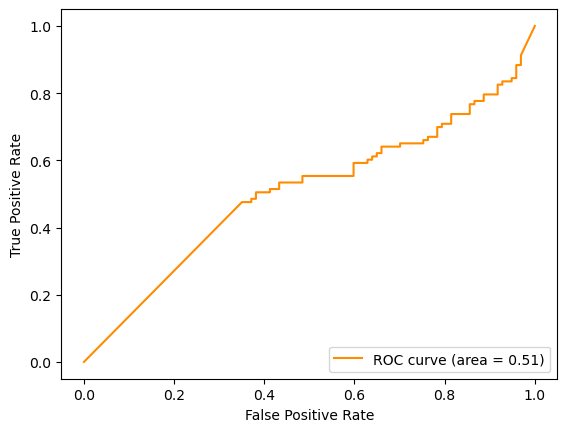

In [45]:
lda = LinearDiscriminantAnalysis(priors=[y_train.value_counts(normalize=True)[1], y_train.value_counts(normalize=True)[0]])
lda.fit(X_train, y_train)
evaluate_model(lda, X_val, Y_val, "Linear Discriminant Analysis")




--- Decision Tree ---
Accuracy: 0.625
ROC AUC: 0.66149534581123
Confusion Matrix:
 [[75 22]
 [53 50]]
              precision    recall  f1-score   support

         0.0       0.59      0.77      0.67        97
         1.0       0.69      0.49      0.57       103

    accuracy                           0.62       200
   macro avg       0.64      0.63      0.62       200
weighted avg       0.64      0.62      0.62       200



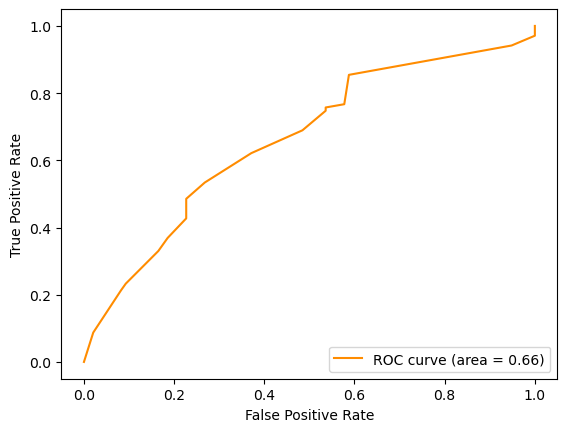

In [46]:
tree = DecisionTreeClassifier(max_depth=5, random_state=100)
tree.fit(X_train, y_train)
evaluate_model(tree, X_val, Y_val, "Decision Tree")


--- Random Forest ---
Accuracy: 0.685
ROC AUC: 0.753728355519968
Confusion Matrix:
 [[66 31]
 [32 71]]
              precision    recall  f1-score   support

         0.0       0.67      0.68      0.68        97
         1.0       0.70      0.69      0.69       103

    accuracy                           0.69       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.69      0.69      0.69       200



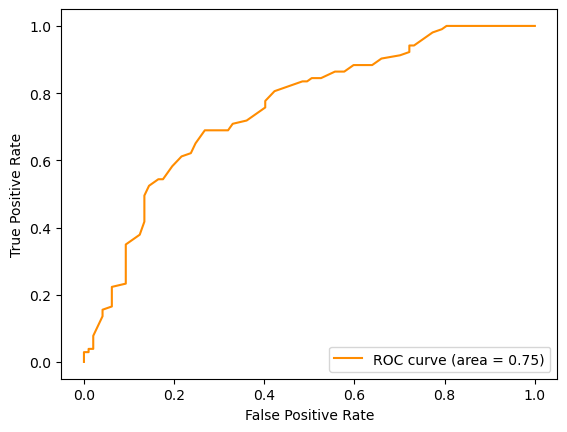

In [47]:
rf = RandomForestClassifier(class_weight='balanced', random_state=100)
rf.fit(X_train, y_train)
evaluate_model(rf, X_val, Y_val, "Random Forest")
